# CAJAL Computational Mini-Project 16

## Level 2 — Exploring effect of transcription factor combinations on neuronal cell type composition.

---

You have been given a single-cell RNA-seq dataset from a large-scale combinatorial morphogen perturbation screen. The dataset was generated using Parse single cell technology and there are 2 plates and 192 perturbations in total. You have now analysed and annotated the perturbation screen data with the types of neuronal cells generated in the screen.

**Important:** Do not look up the source paper for this dataset yet.


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bokeh.core.property import color

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(5, 4))
sns.set_style("whitegrid")

%matplotlib inline

/var/folders/20/gn3rx00s4cqbr_7_trp61mdr0000gq/T/ipykernel_7456/2796862692.py:9: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(5, 4))


In [2]:
# ---- category display orders -------------------------------------------------
AP_ORDER = ["ctrl",
            "XAV_1", "XAV_2", "XAV_3",
            "CHIR_1", "CHIR_2", "CHIR_3", "CHIR_4",
            "RA_1", "RA_2", "RA_3", "RA_4",
            "RA_1_CHIR", "RA_2_CHIR", "RA_3_CHIR", "RA_4_CHIR",
            "FGF8_1", "FGF8_2", "FGF8_3", "FGF8_4",
            "FGF8_1_CHIR", "FGF8_2_CHIR", "FGF8_3_CHIR", "FGF8_4_CHIR"]
DV_ORDER = ["ctrl", "BMP4_1", "BMP4_2", "BMP4_3",
            "SHH_1", "SHH_2", "SHH_3", "SHH_4"]
REGION_ORDER = ["Forebrain", "Midbrain", "Hindbrain", "Spinal cord",
                "SYM", "ENS", "TG", "DRG"]
NEURON_ORDER = ["GLUT", "CHO", "NOR", "NBL"]

# ---- colours
REGION_COLORS = {"Forebrain": "#fe9b00", "Midbrain": "#f4c40f",
                 "Hindbrain": "#d8443c", "Spinal cord": "#9b3441",
                 "SYM": "#268a8a", "ENS": "#226a99",
                 "TG": "#383b81", "DRG": "#92c051"}
NEURON_COLORS = {"GLUT": "#fe9b00", "CHO": "#33A02C",
                 "NOR": "#383b81", "NBL": "#c9bba2"}

# AP / DV levels graded light -> dark within each morphogen group
AP_COLORS = {
    "ctrl": "#E5E5E5",
    "XAV_1": "#f9b4c9", "XAV_2": "#d8527c", "XAV_3": "#9a133d",
    "CHIR_1": "#dec5da", "CHIR_2": "#b695bc", "CHIR_3": "#90719f", "CHIR_4": "#574571",
    "RA_1": "#aadce0", "RA_2": "#72bcd5", "RA_3": "#528fad", "RA_4": "#376795",
    "RA_1_CHIR": "#c2d6a4", "RA_2_CHIR": "#9cc184", "RA_3_CHIR": "#669d62", "RA_4_CHIR": "#3c7c3d",
    "FGF8_1": "#FFBBFF", "FGF8_2": "#EE7AE9", "FGF8_3": "#B452CD", "FGF8_4": "#8B008B",
    "FGF8_1_CHIR": "#CCCCCC", "FGF8_2_CHIR": "#999999", "FGF8_3_CHIR": "#666666", "FGF8_4_CHIR": "#333333"}
DV_COLORS = {
    "ctrl": "#E5E5E5",
    "BMP4_1": "#ffe6b7", "BMP4_2": "#ffd353", "BMP4_3": "#ffb242",
    "SHH_1": "#C2D9F7", "SHH_2": "#98C1F0", "SHH_3": "#4782DD", "SHH_4": "#1D52A1"}

## 1. Setup and Data Loading

In [3]:
adata = sc.read_h5ad("data/ngn2_scrna_processed.h5ad", backed="r")
adata.obs_names = adata.obs_names + "_" + adata.obs["plateID"].astype(str)
obs = adata.obs

obs[["parse_id", "AP_axis", "DV_axis", "Region", "Neuron_type"]].head()

/Users/ay334/PycharmProjects/cajal_neuromics_project/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


,parse_id,AP_axis,DV_axis,Region,Neuron_type
01_01_02__s1_iGlut_post_p1,p1_A1,XAV_3,BMP4_3,TG,NOR
01_01_12__s1_iGlut_post_p1,p1_A1,XAV_3,BMP4_3,TG,NOR
01_01_16__s1_iGlut_post_p1,p1_A1,XAV_3,BMP4_3,TG,GLUT
01_01_22__s1_iGlut_post_p1,p1_A1,XAV_3,BMP4_3,DRG,GLUT
01_01_55__s1_iGlut_post_p1,p1_A1,XAV_3,BMP4_3,DRG,GLUT


## 2. Data exploration

We want to understand the effect of the different transcription factor combination and concentration on the types of neuron generated. One way to approach this is to look at the composition of neuronal cell (e.g. by region, neuron type and/or division) for each morphogen combination. Hint: you may need to use `pd.crosstab` with `normalize="index"` counts the cells of each category in every sample and turns each row into fractions that sum to 1.

### 2.1. Neuronal region composition

In [6]:
# .astype(str) keeps the columns/index as plain text (simpler to work with)
region_frac = pd.crosstab(obs["parse_id"].astype(str),
                          obs["Region"].astype(str), normalize="index")

print("shape:", region_frac.shape, "(192 samples x regions)")
region_frac.head()

shape: (192, 7) (192 samples x regions)


Region,DRG,ENS,Forebrain,Hindbrain,Midbrain,Spinal cord,TG
parse_id,,,,,,,
p1_A1,0.284503,0.089437,0.055513,0.010023,0.016191,0.005397,0.538936
p1_A10,0.096664,0.002042,0.004765,0.863853,0.000681,0.000000,0.031995
p1_A11,0.508235,0.063529,0.058039,0.166275,0.010196,0.000784,0.192941
p1_A12,0.291699,0.057409,0.109387,0.007758,0.041117,0.006982,0.485648
p1_A2,0.276143,0.050094,0.113964,0.011897,0.039449,0.006262,0.502192


We also need to know which treatment each sample got. Since every sample has a
single `AP_axis` and `DV_axis` value, we can grab one row per sample.

In [7]:
sample_info = (obs[["parse_id", "AP_axis", "DV_axis"]]
               .astype({"parse_id": str})
               .drop_duplicates()
               .set_index("parse_id"))
sample_info.head()

,AP_axis,DV_axis
parse_id,,
p1_A1,XAV_3,BMP4_3
p1_A2,XAV_2,BMP4_3
p1_A3,XAV_1,BMP4_3
p1_A4,ctrl,BMP4_3
p1_A5,CHIR_1,BMP4_3


To make the plot result easier to interpret, we will use the predefined order for the AP and DV axis above.

In [8]:
# make the columns ordered categories so sorting / plotting respects the order
sample_info["AP_axis"] = pd.Categorical(sample_info["AP_axis"], AP_ORDER, ordered=True)
sample_info["DV_axis"] = pd.Categorical(sample_info["DV_axis"], DV_ORDER, ordered=True)

Now we can visualise the the region composition per sample. Since we have 192 samples, it will be rather difficult to interpret a bar chart with all 192 samples, especially if there is no clear legend. As such, let's split the plot by DV condition since there is less DV condition compared to AP condition. Start by creating a stack bar chart for one DV condition (e.g. ctrl).

Text(0, 0.5, 'Frequency')

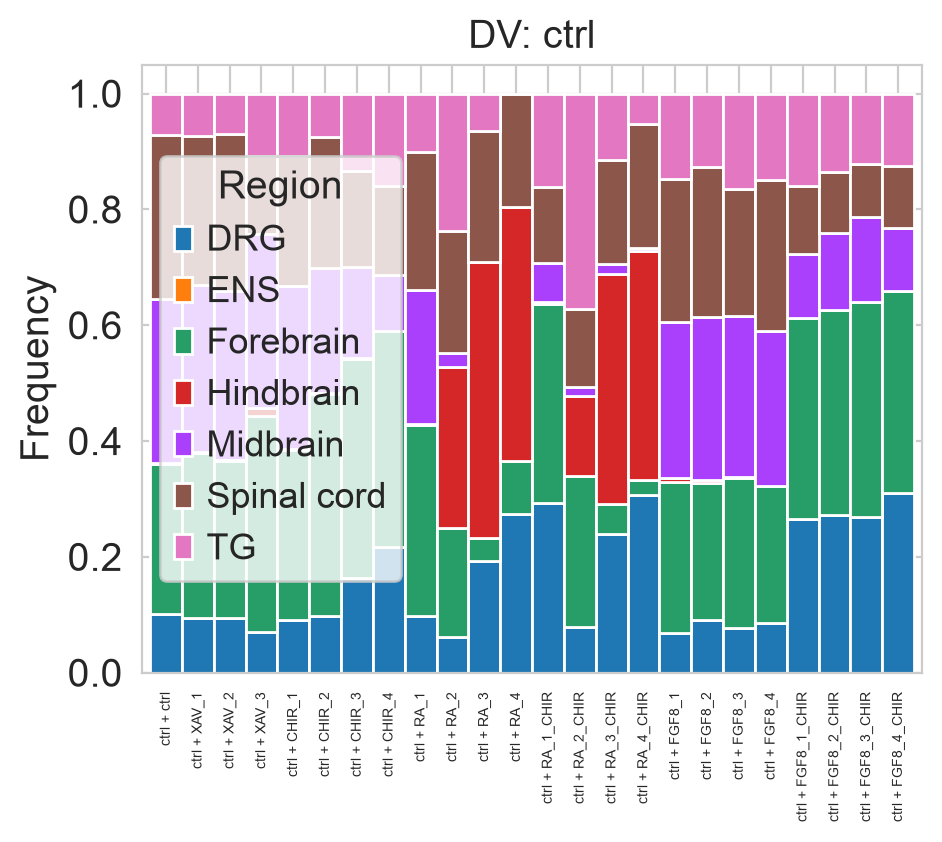

In [9]:
ids = sample_info[sample_info["DV_axis"] == "ctrl"].sort_values("AP_axis").index
ax = region_frac.loc[ids].plot(kind="bar", stacked=True, width=1.0)

# "DV + AP" label for each bar in this subplot
labels = (sample_info.loc[ids, "DV_axis"].astype(str)
          + " + " + sample_info.loc[ids, "AP_axis"].astype(str))
ax.set_title(f"DV: ctrl")
ax.set_xticks(range(len(ids)))
ax.set_xticklabels(labels, rotation=90, fontsize=5)
ax.set_xlabel("")
ax.set_ylabel("Frequency")

Now generate this for all DV combination, with each plot being a subplot.

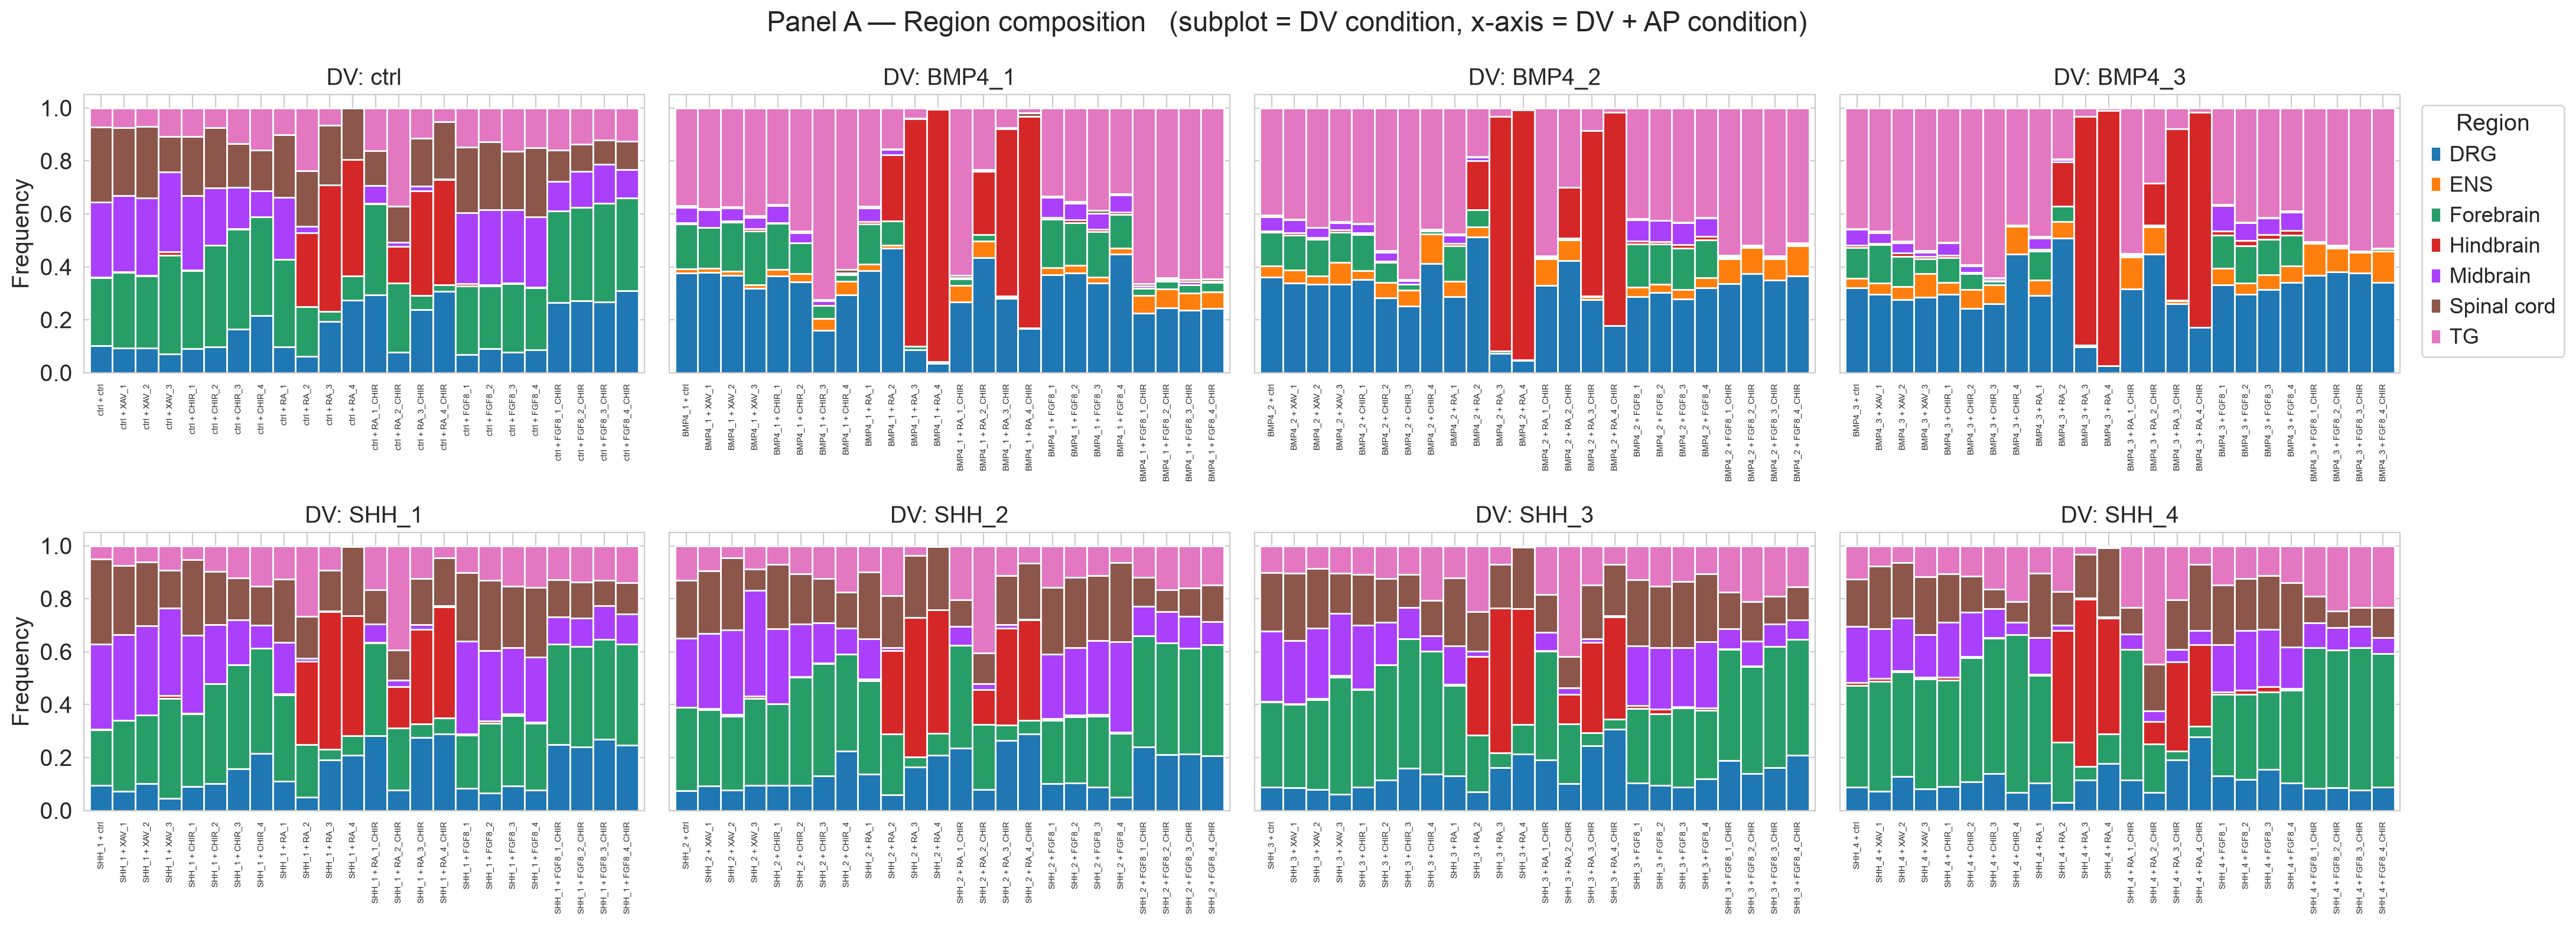

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(22, 8), sharey=True)

for ax, dv in zip(axes.flat, DV_ORDER):
    ids = sample_info[sample_info["DV_axis"] == dv].sort_values("AP_axis").index
    region_frac.loc[ids].plot(kind="bar", stacked=True, width=1.0, ax=ax, legend=False)

    # "DV + AP" label for each bar in this subplot
    labels = (sample_info.loc[ids, "DV_axis"].astype(str)
              + " + " + sample_info.loc[ids, "AP_axis"].astype(str))
    ax.set_title(f"DV: {dv}")
    ax.set_xticks(range(len(ids)))
    ax.set_xticklabels(labels, rotation=90, fontsize=5)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

# one shared legend (taken from the top-right subplot)
axes.flat[3].legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Panel A — Region composition   (subplot = DV condition, x-axis = DV + AP condition)")
plt.tight_layout()
plt.show()

While the stacked barplot visualisation may be useful to quickly glance at the regional composition of the cell, it is a bit hard to compare the fraction of cells per region across samples. In this case, something like a boxplot showing the distribution of cell fraction might be helpful.

You should use seaborn `catplot` to generate the boxplots. However, seaborn expect the data to be in a 'tidy' format, with one row per (sample, category), with a `freq` column. `melt` does exactly that. We attach the treatment columns first.

In [13]:
region_long = (region_frac
               .join(sample_info)                 # add AP_axis, DV_axis
               .melt(id_vars=["AP_axis", "DV_axis"],
                     var_name="Region", value_name="freq"))
region_long.head()

,AP_axis,DV_axis,Region,freq
0,XAV_3,BMP4_3,DRG,0.284503
1,RA_3,BMP4_3,DRG,0.096664
2,RA_2,BMP4_3,DRG,0.508235
3,RA_1,BMP4_3,DRG,0.291699
4,XAV_2,BMP4_3,DRG,0.276143


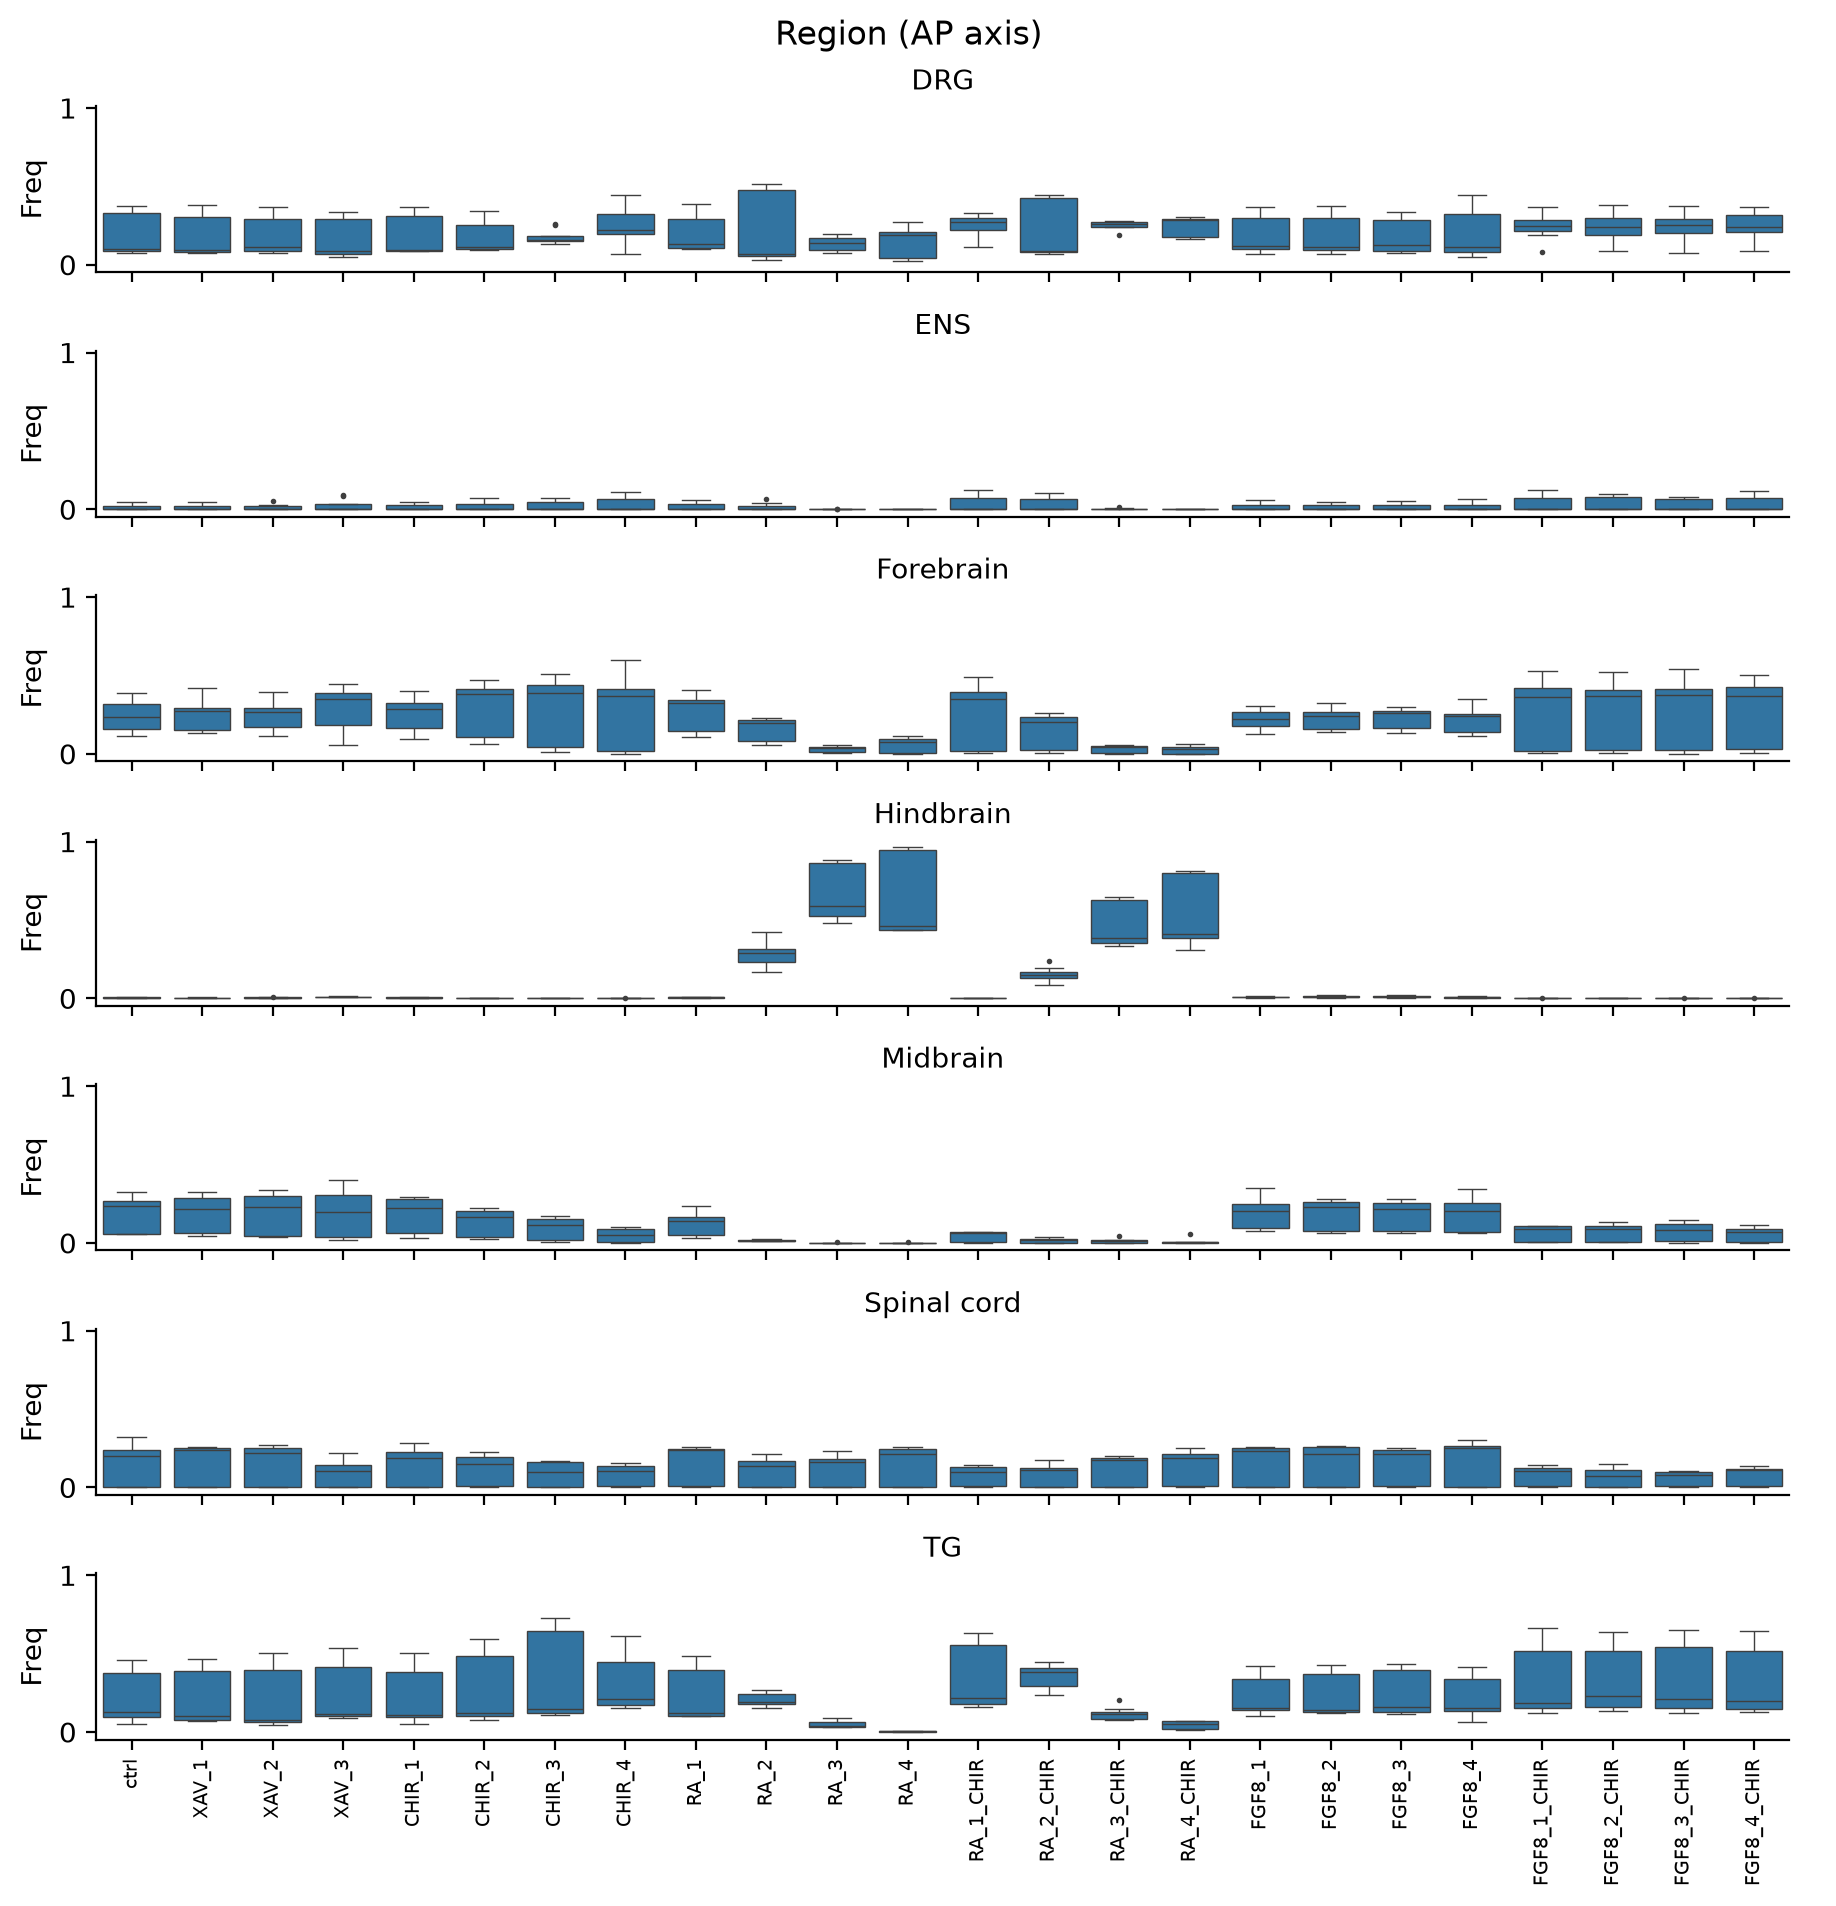

In [14]:
g = sns.catplot(data=region_long, x="AP_axis", y="freq", row="Region",
                kind="box", order=AP_ORDER,
                height=1.3, aspect=7,
                fliersize=1, linewidth=0.5, sharey=True)
g.set_titles(row_template="{row_name}")
g.set_axis_labels("", "Freq")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
g.figure.suptitle("Region (AP axis)", y=1.01)
plt.show()

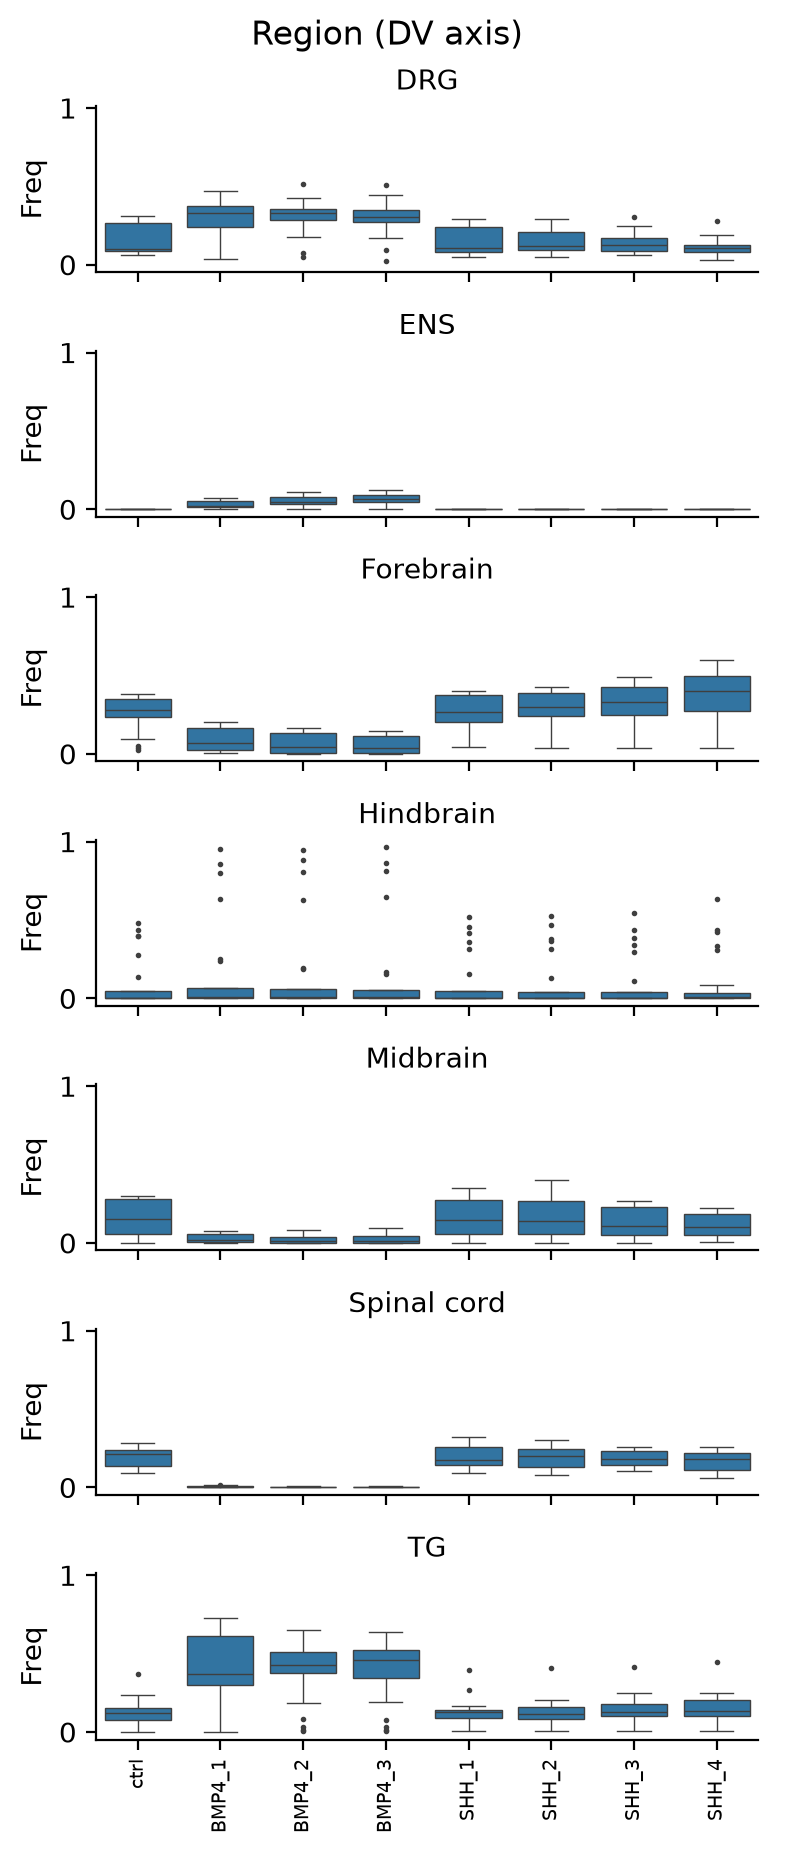

In [15]:
g = sns.catplot(data=region_long, x="DV_axis", y="freq", row="Region",
                kind="box", order=DV_ORDER,
                height=1.3, aspect=3,
                fliersize=1, linewidth=0.5, sharey=True)
g.set_titles(row_template="{row_name}")
g.set_axis_labels("", "Freq")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
g.figure.suptitle("Region (DV axis)", y=1.01)
plt.show()

### 2.2. Neuronal type composition

We will focus on the neuronal type and we will generate similar plots as above.

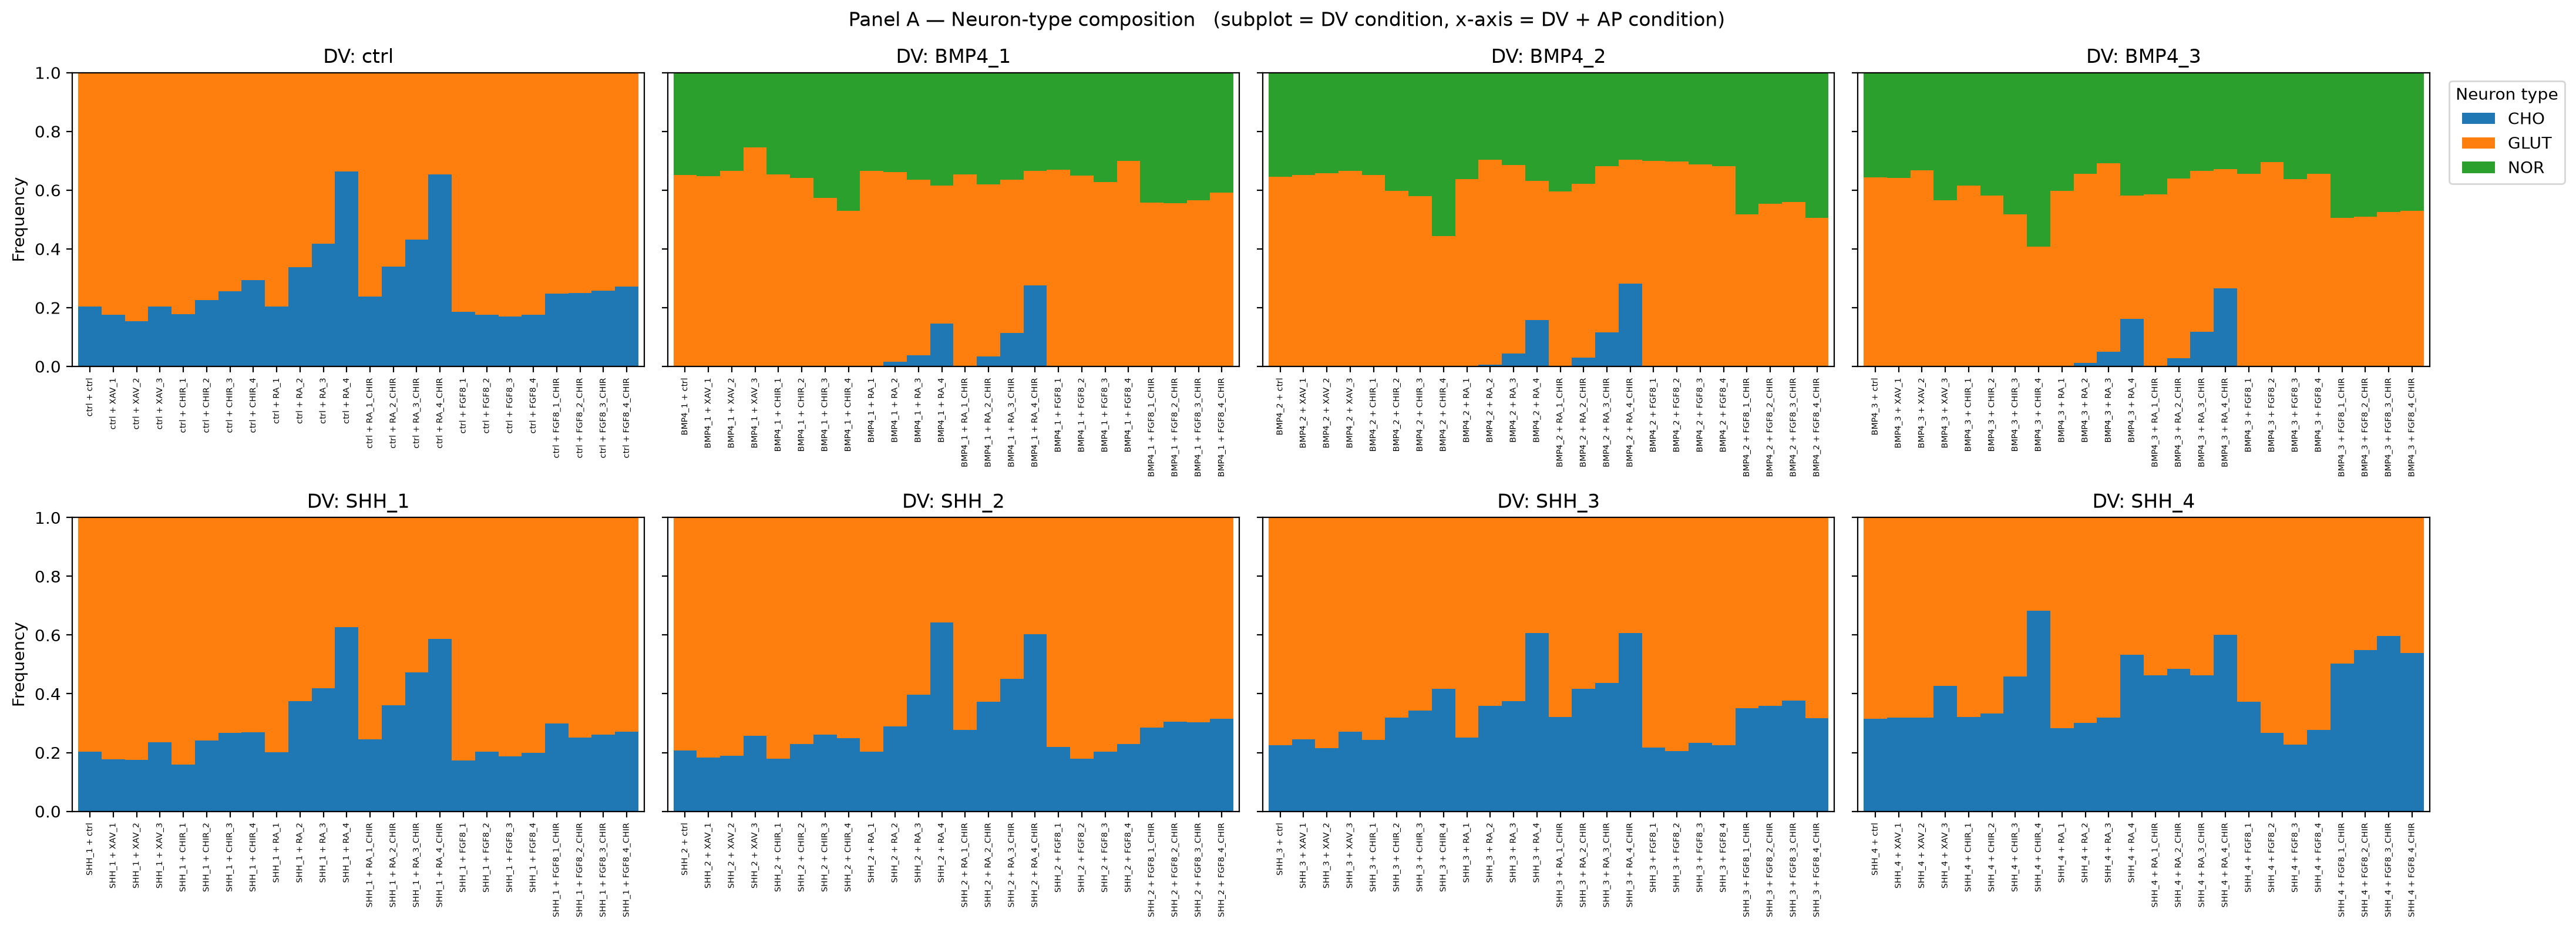

In [16]:
neuron_frac = pd.crosstab(obs["parse_id"].astype(str),
                          obs["Neuron_type"].astype(str), normalize="index")

fig, axes = plt.subplots(2, 4, figsize=(22, 8), sharey=True)

for ax, dv in zip(axes.flat, DV_ORDER):
    ids = sample_info[sample_info["DV_axis"] == dv].sort_values("AP_axis").index
    neuron_frac.loc[ids].plot(kind="bar", stacked=True, width=1.0, ax=ax, legend=False)

    labels = (sample_info.loc[ids, "DV_axis"].astype(str)
              + " + " + sample_info.loc[ids, "AP_axis"].astype(str))
    ax.set_title(f"DV: {dv}")
    ax.set_xticks(range(len(ids)))
    ax.set_xticklabels(labels, rotation=90, fontsize=5)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

axes.flat[3].legend(title="Neuron type", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Panel A — Neuron-type composition   (subplot = DV condition, x-axis = DV + AP condition)")
plt.tight_layout()
plt.show()

In [17]:
neuron_long = (neuron_frac
               .join(sample_info)
               .melt(id_vars=["AP_axis", "DV_axis"],
                     var_name="Neuron_type", value_name="freq"))
neuron_long.head()

,AP_axis,DV_axis,Neuron_type,freq
0,XAV_3,BMP4_3,CHO,0.000771
1,RA_3,BMP4_3,CHO,0.050374
2,RA_2,BMP4_3,CHO,0.010980
3,RA_1,BMP4_3,CHO,0.000776
4,XAV_2,BMP4_3,CHO,0.000000


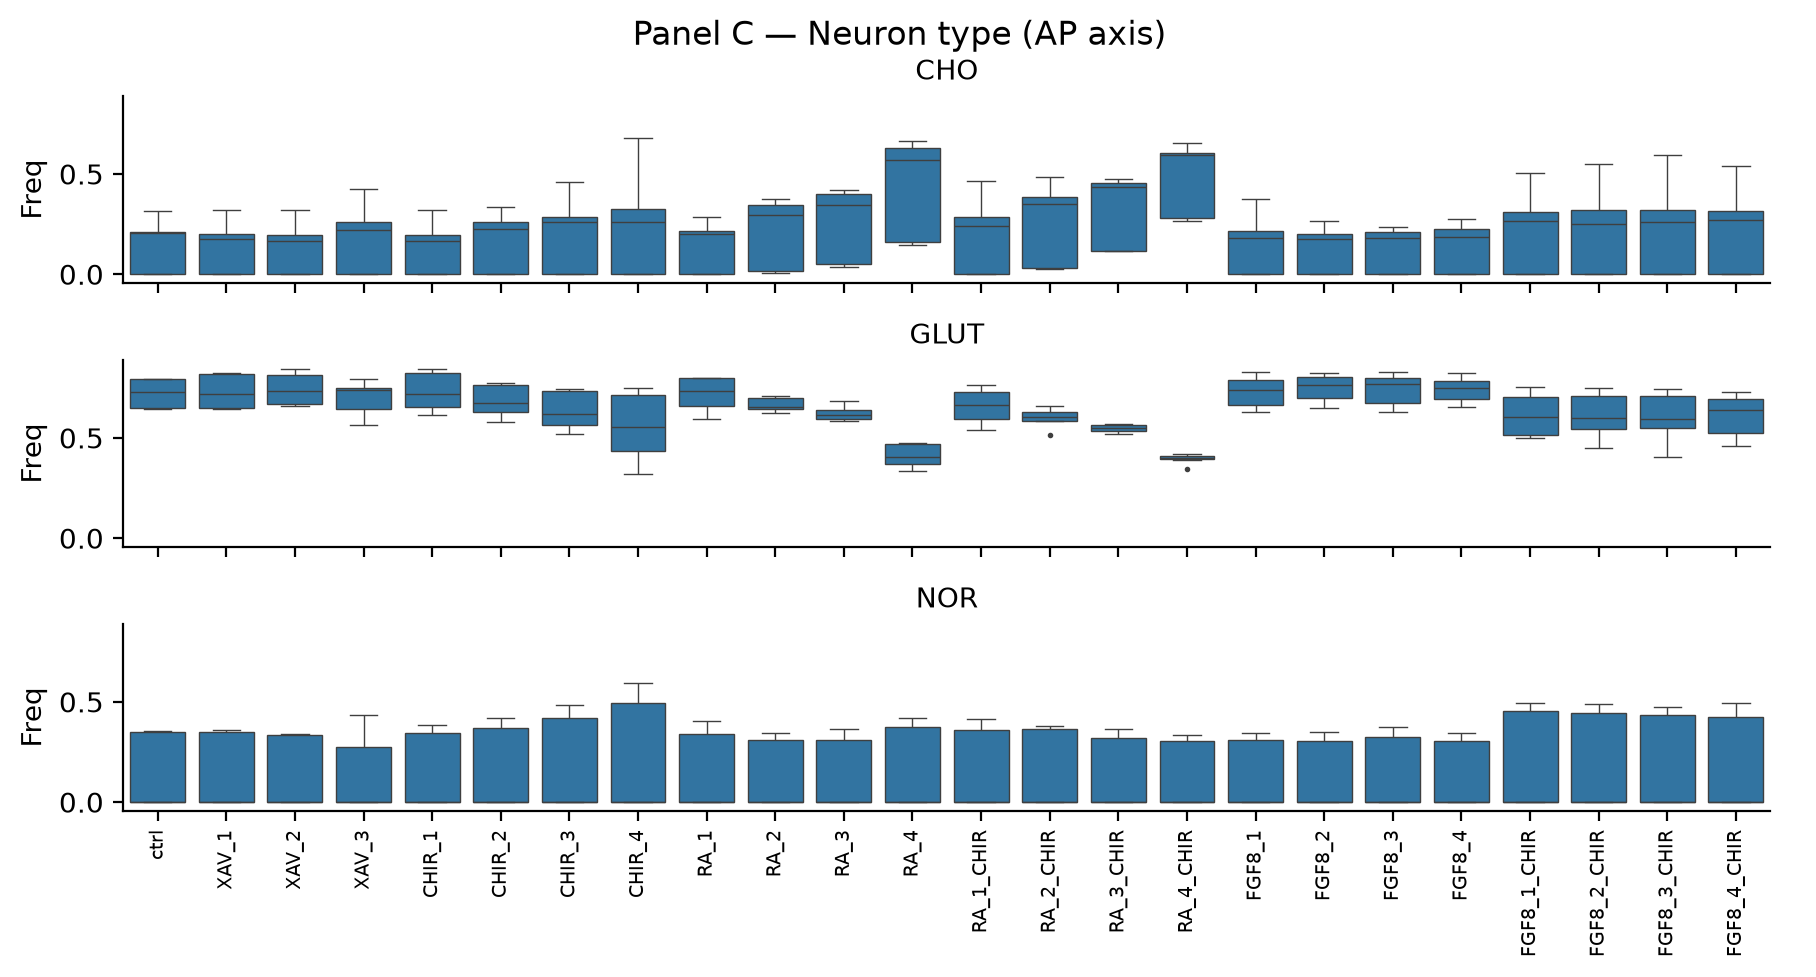

In [18]:
g = sns.catplot(data=neuron_long, x="AP_axis", y="freq", row="Neuron_type",
                kind="box", order=AP_ORDER,
                height=1.5, aspect=6,
                fliersize=1, linewidth=0.5, sharey=True)
g.set_titles(row_template="{row_name}")
g.set_axis_labels("", "Freq")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
g.figure.suptitle("Panel C — Neuron type (AP axis)", y=1.01)
plt.show()

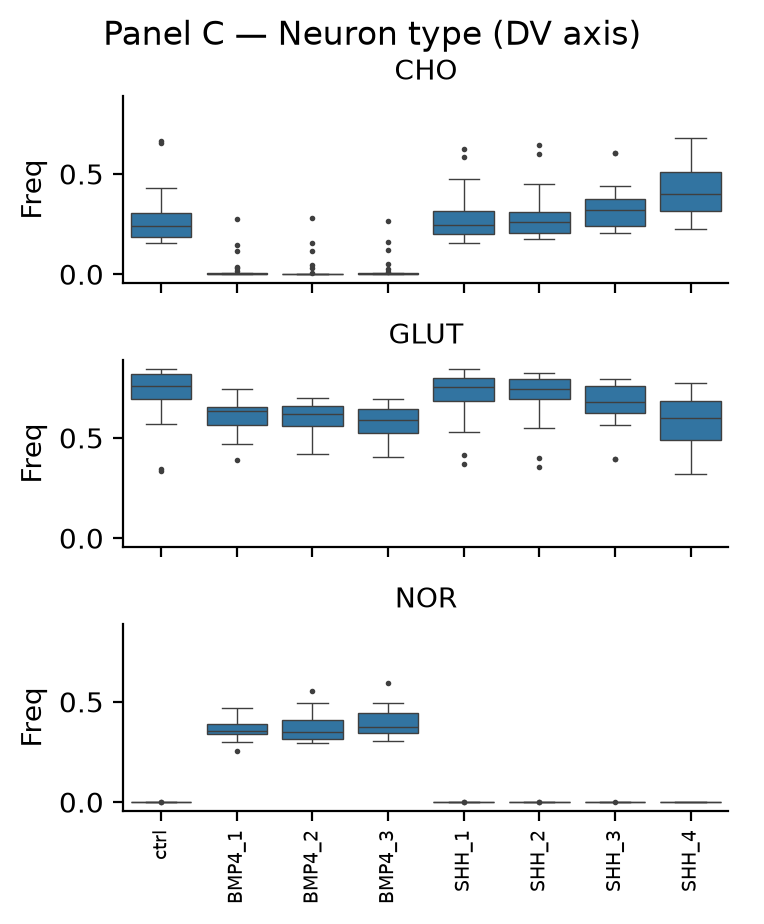

In [19]:
g = sns.catplot(data=neuron_long, x="DV_axis", y="freq", row="Neuron_type",
                kind="box", order=DV_ORDER,
                height=1.5, aspect=2.5,
                fliersize=1, linewidth=0.5, sharey=True)
g.set_titles(row_template="{row_name}")
g.set_axis_labels("", "Freq")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
g.figure.suptitle("Panel C — Neuron type (DV axis)", y=1.01)
plt.show()

Now comes the biological intepretation. Have a look at the plots you have generated and explore the effect of the morphogens on the regional identity and neuronal type being generated. Here are some questions to get you started:

* Which AP treatments increase **Hindbrain** identity?
* Under which DV treatment do **NOR** neurons appear?
* What dominates the **control** samples?

----

## 3. Replicating main figures from paper

So far, we have analysed the effect of the perturbation at the cell level. While this is useful, this does not necessarily tell us the diversity of cell types generated by the morphogen screen. Similarly, in the paper from which this data came from, the authors focused primarily on the number and types of clusters (as a proxy for cell types) generated by the morphogen screen in the main figures.

Before we reveal the source of the paper and show you the figures the authors have generated, can you come up with ideas of how to show the diversity of cell types (i.e. clusters) for each morphogen combinations?

Now that you have come up and created some figures to show the cell type diversity, let's look at the figures from the [paper](https://www.science.org/doi/10.1126/science.adn6121). In particular, we will focus on figure 3 panel A-C which summarises the result of the morphogen screen.

### 3.1 Panel A

In [34]:
cluster_property = obs.groupby("cell_type", observed=True)[["Region", "Neuron_type", "Division"]].first()

/Users/ay334/PycharmProjects/cajal_neuromics_project/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/ay334/PycharmProjects/cajal_neuromics_project/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


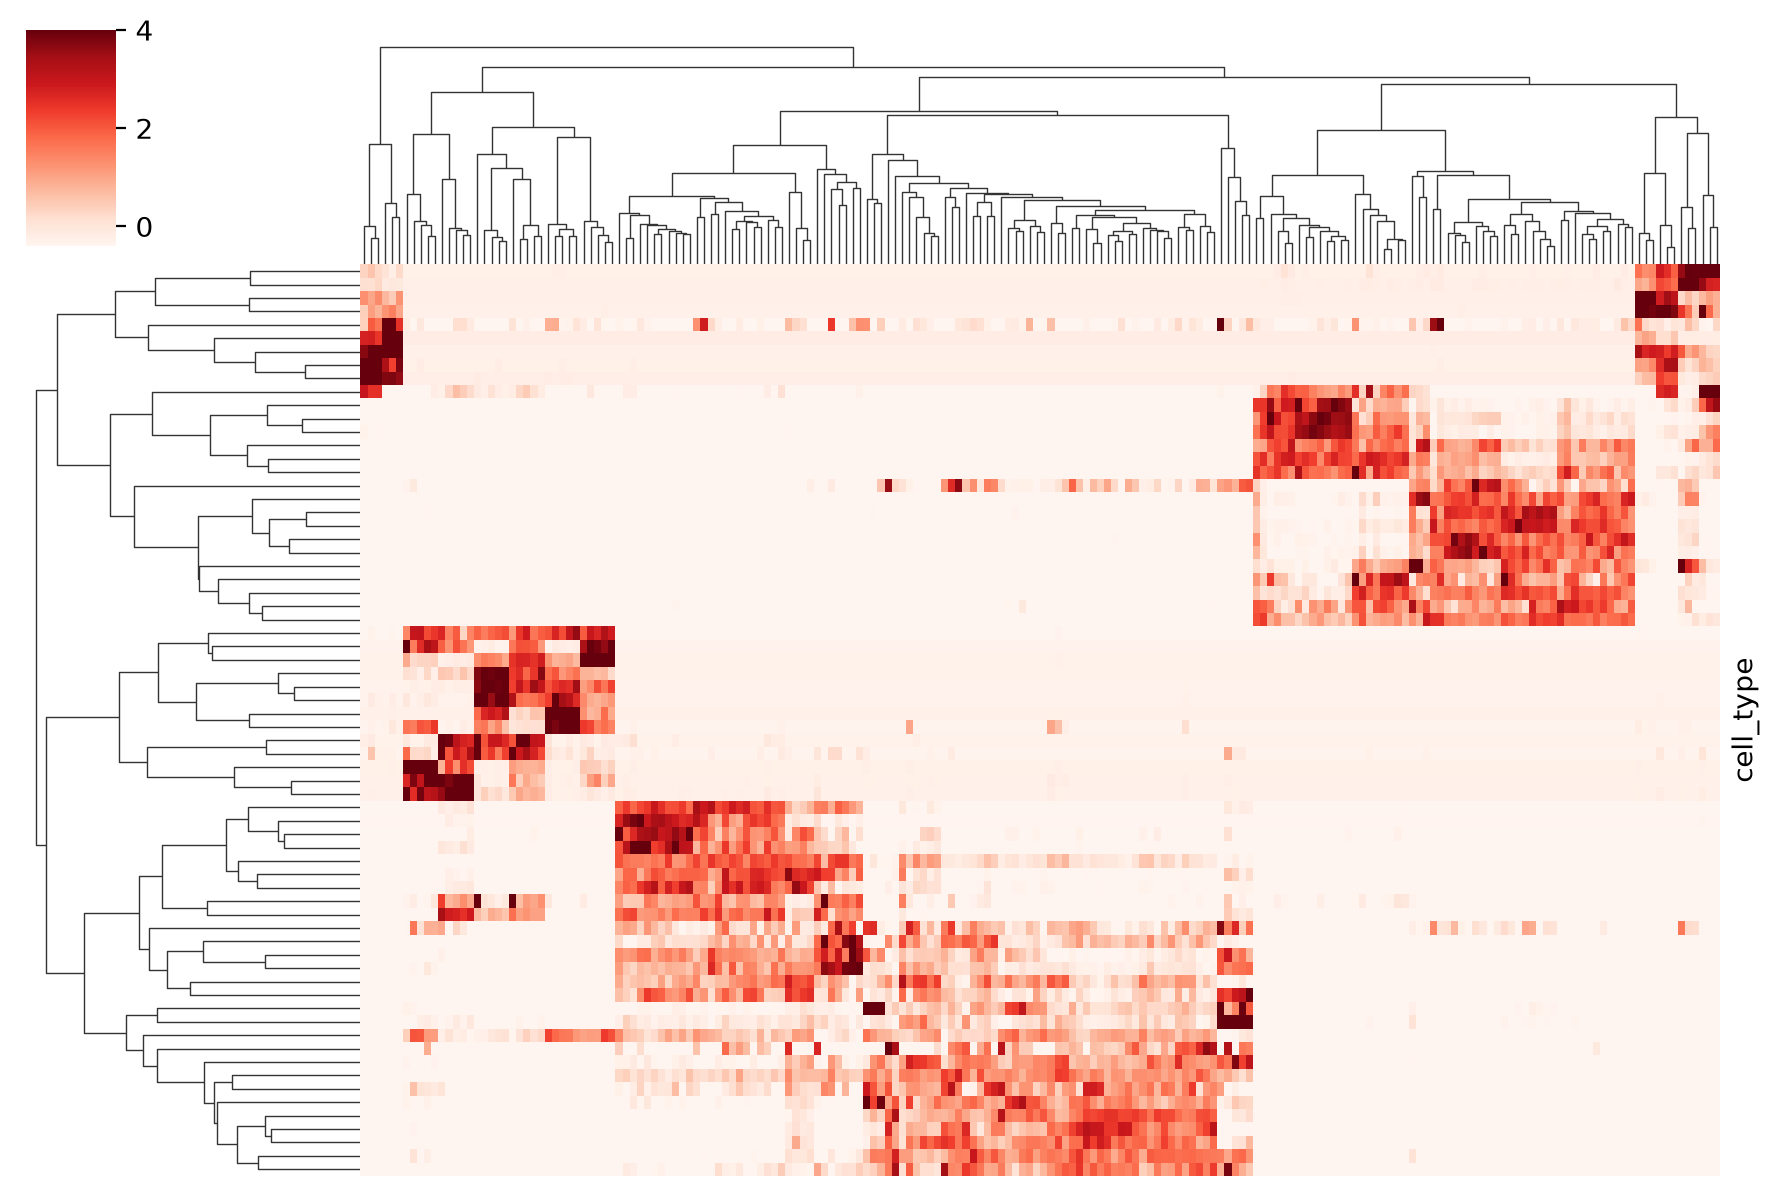

In [36]:
# cluster composition per condition, then z-score each cluster across conditions
comp = (obs.groupby(["AP_axis", "DV_axis"], observed=True)["cell_type"].value_counts(normalize=True).unstack(fill_value=0))
comp.index = [f"{ap}|{dv}" for ap, dv in comp.index]
M = comp.T                                                       # clusters x 192 conditions
Z = (M.sub(M.mean(axis=1), axis=0)
       .div(M.std(axis=1).replace(0, np.nan), axis=0).fillna(0))

# BASIC PLOT: a single seaborn.clustermap call
sns.clustermap(Z, cmap="Reds", vmin=-0.4, vmax=4,
               xticklabels=False, yticklabels=False, figsize=(9, 6))
plt.show()

/Users/ay334/PycharmProjects/cajal_neuromics_project/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/ay334/PycharmProjects/cajal_neuromics_project/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


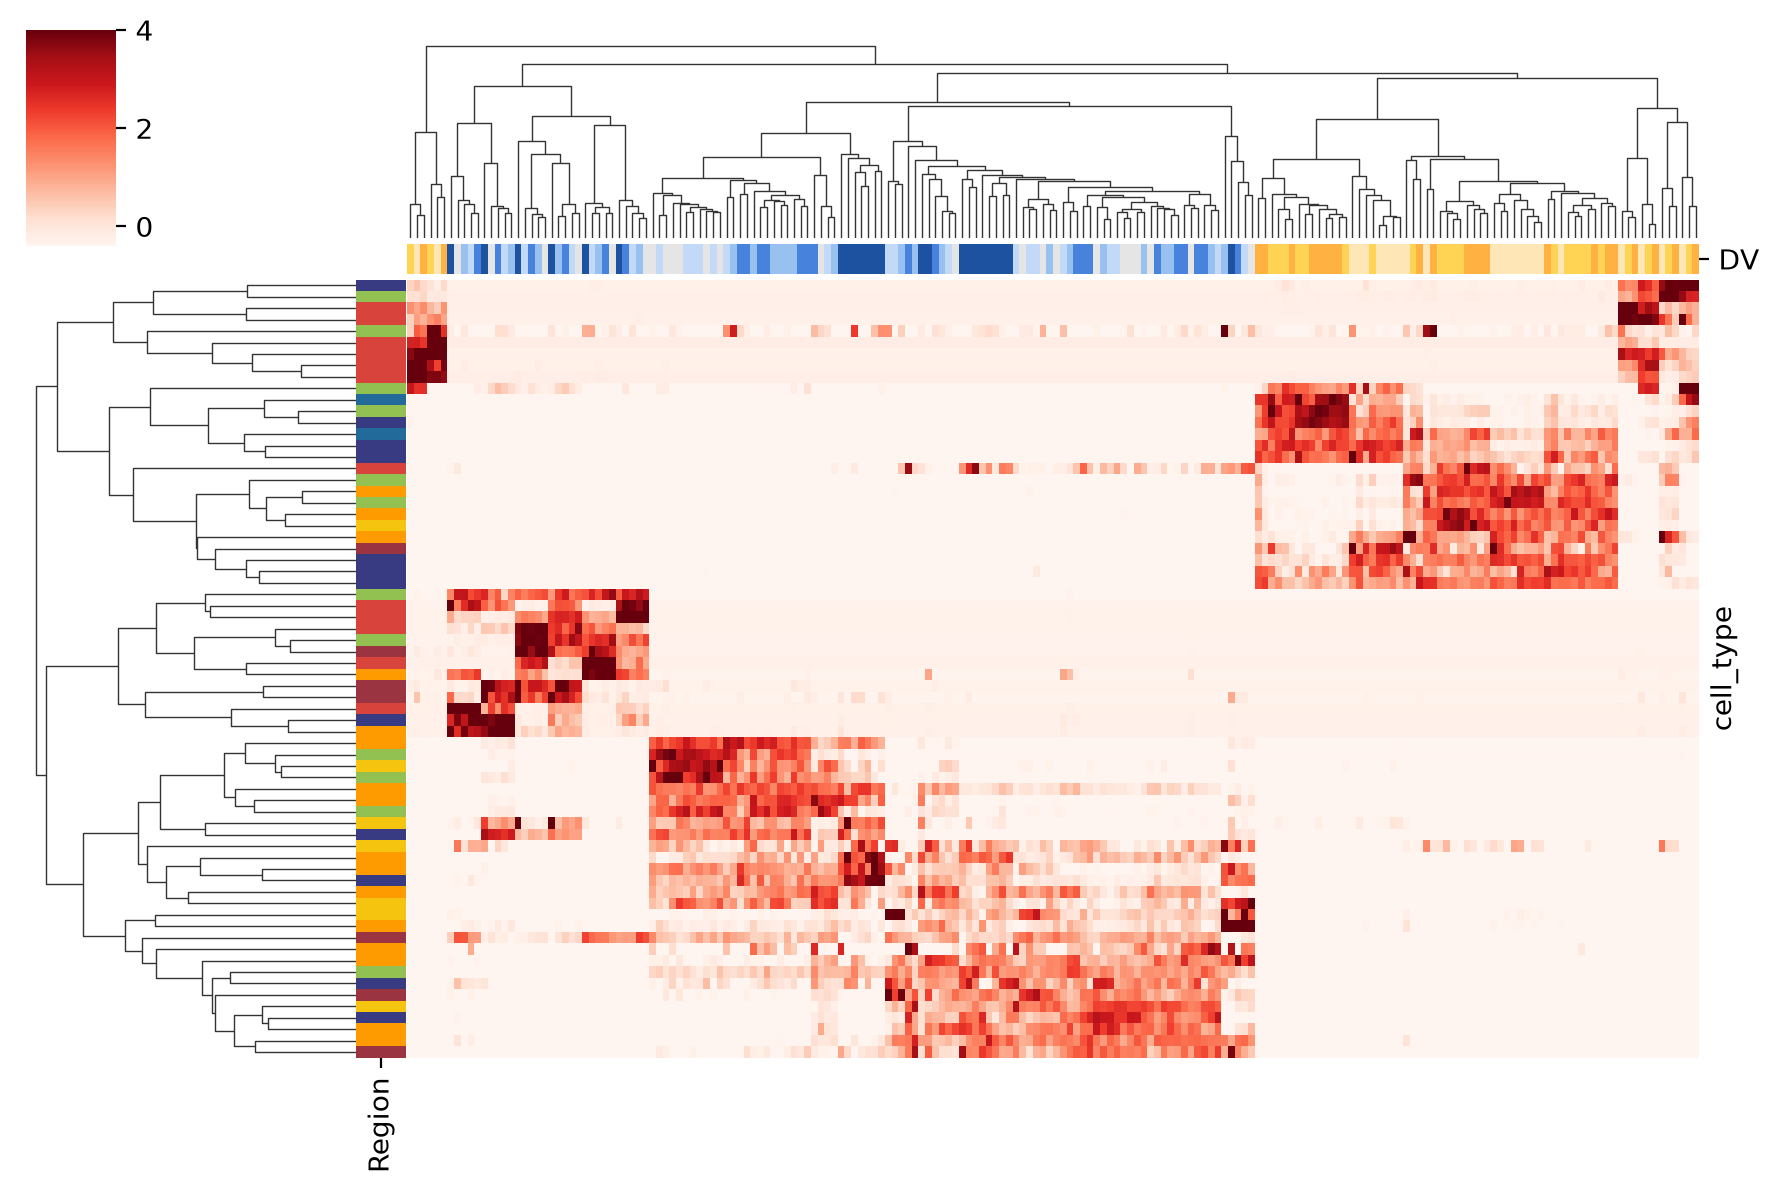

In [37]:
# FIX: add colour strips so rows/columns map back to biology (still one clustermap call).
cond_dv    = pd.Series({c: c.split("|")[1] for c in M.columns}).map(DV_COLORS).rename("DV")
clust_reg  = cluster_property["Region"].reindex(M.index).map(REGION_COLORS).rename("Region")

sns.clustermap(Z, cmap="Reds", vmin=-0.4, vmax=4,
               xticklabels=False, yticklabels=False, figsize=(9, 6),
               col_colors=cond_dv, row_colors=clust_reg)
plt.show()

### 3.2 Panel B

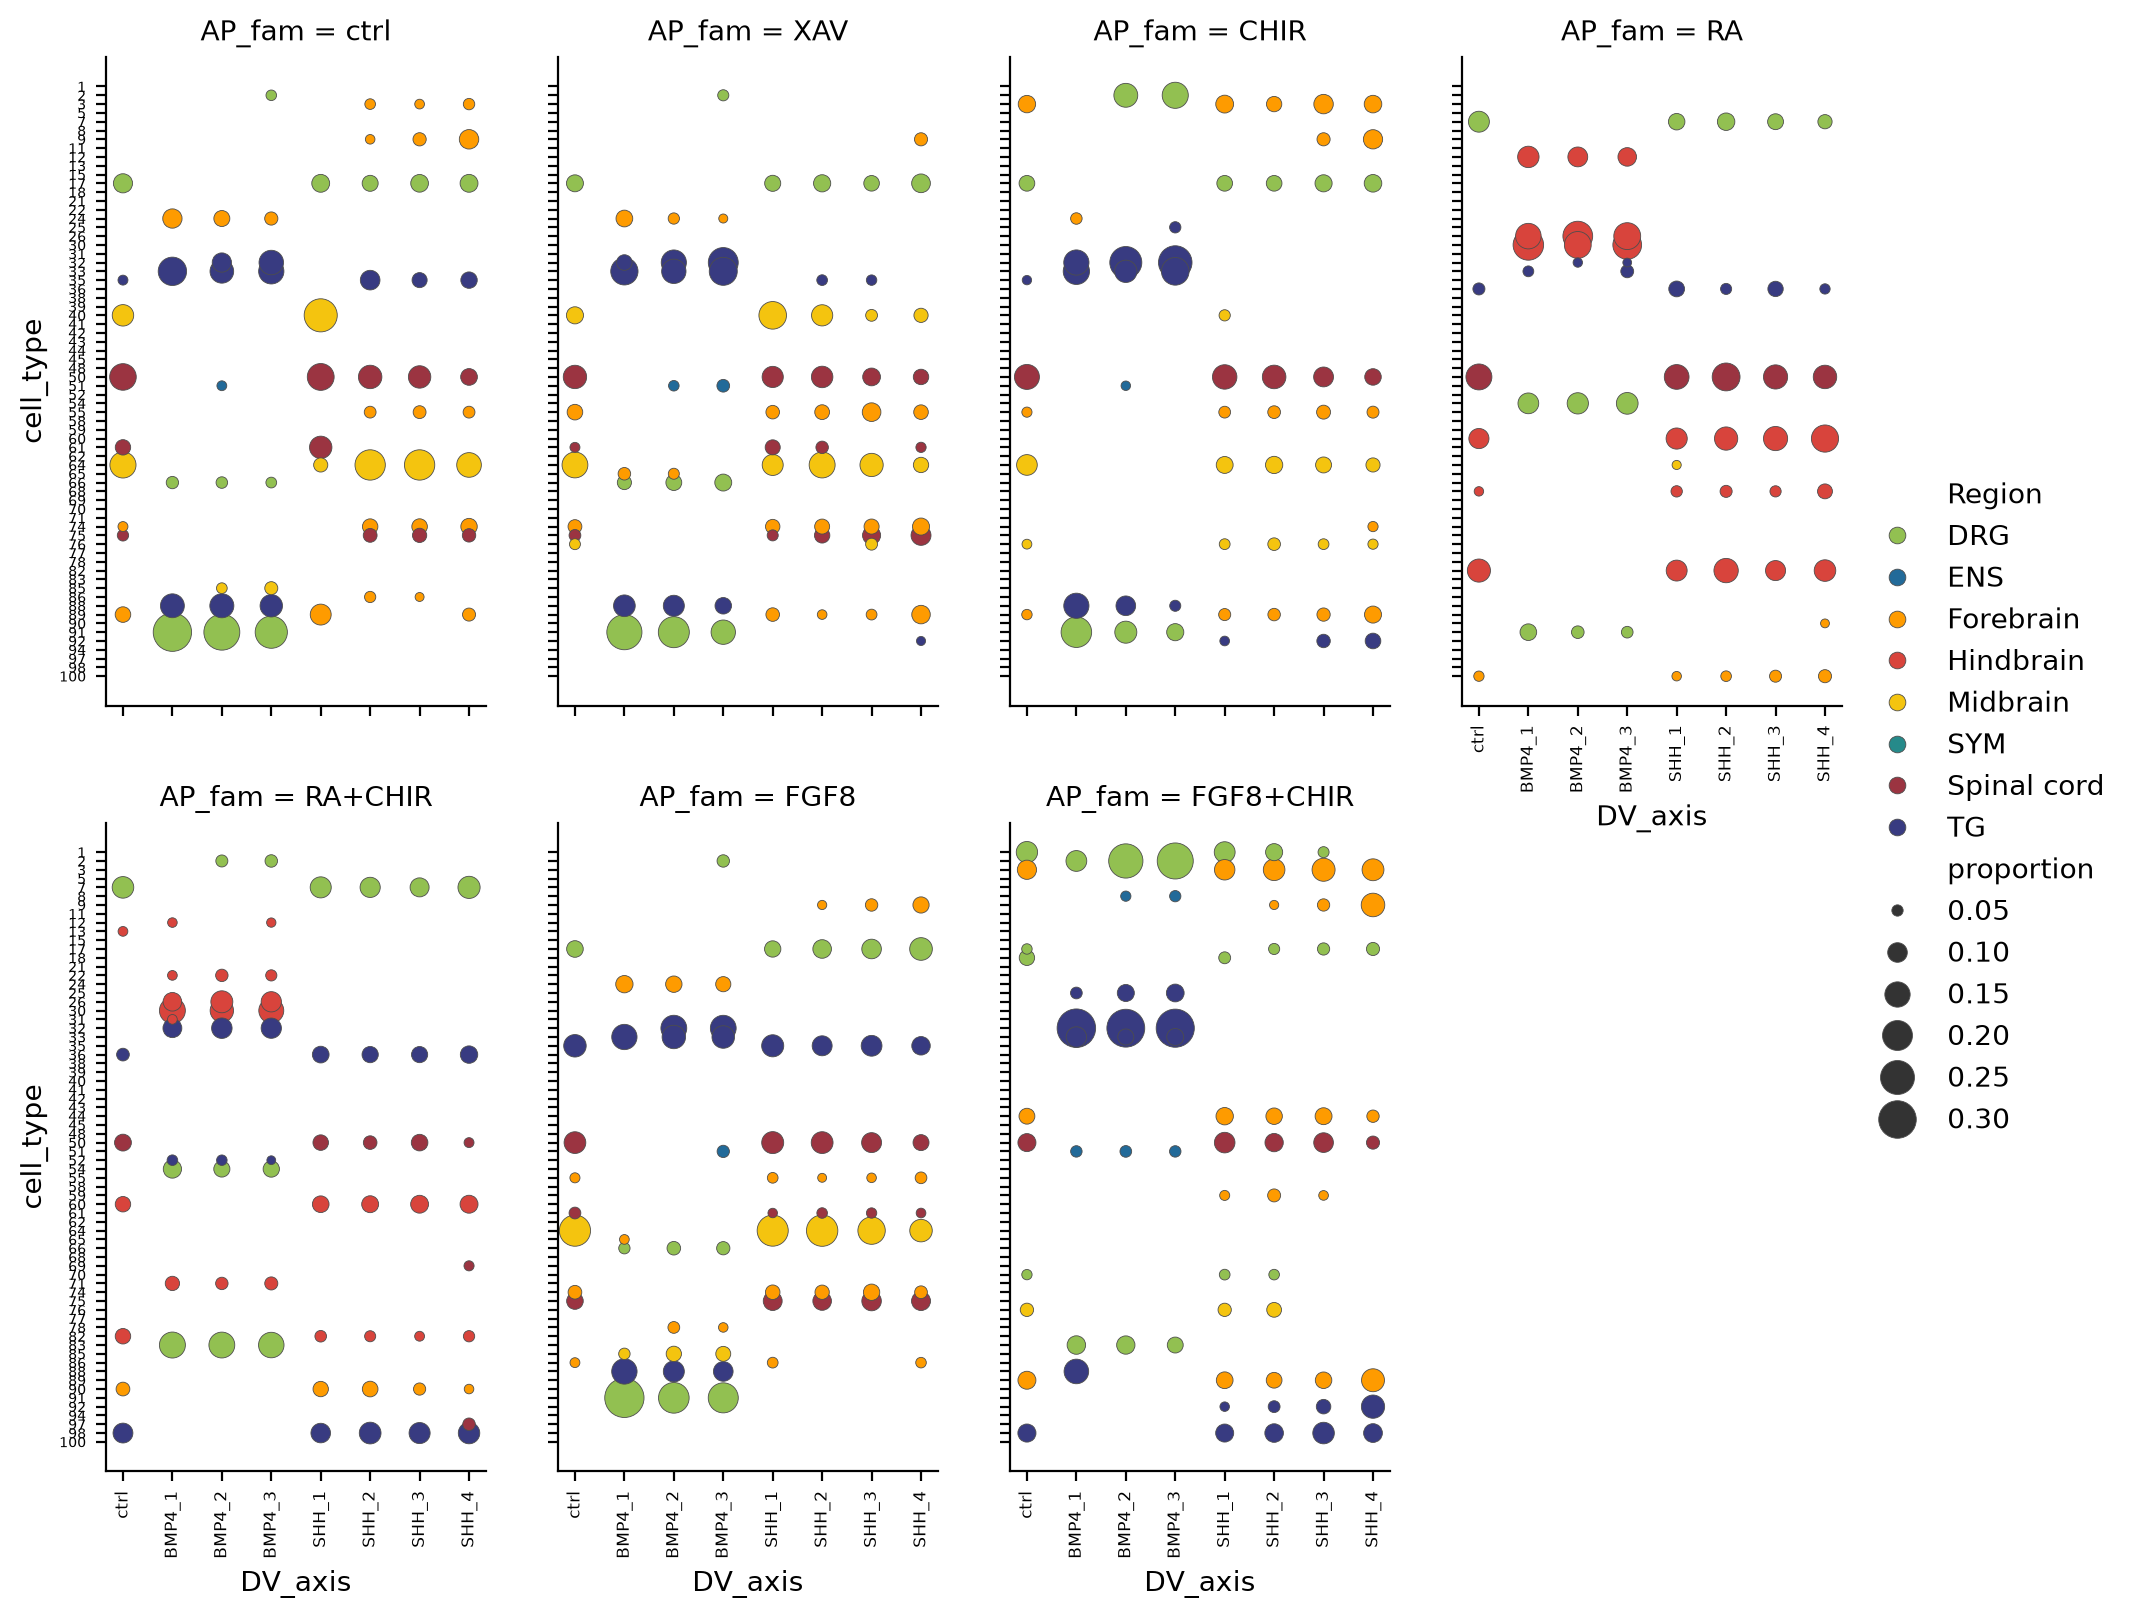

In [38]:
# FIX: keep the AP axis instead of averaging it away - facet by AP morphogen family.
ap_fam = (obs["AP_axis"].astype(str)
             .str.replace(r"_\d+", "", regex=True)         # drop the concentration level
             .str.replace("_CHIR", "+CHIR", regex=False)
             .replace({"": "ctrl"}))

dv2 = (obs.assign(AP_fam=ap_fam)
          .groupby(["AP_fam", "DV_axis"], observed=True)["cell_type"]
          .value_counts(normalize=True).rename("proportion").reset_index())
dv2["Region"] = dv2["cell_type"].map(cluster_property["Region"])
dv2 = dv2[dv2["proportion"] > 0.04]
dv2["DV_axis"] = pd.Categorical(dv2["DV_axis"], DV_ORDER, ordered=True)
fam_order = [f for f in ["ctrl", "XAV", "CHIR", "RA", "RA+CHIR", "FGF8", "FGF8+CHIR"]
            if f in set(dv2["AP_fam"])]
dv2["AP_fam"] = pd.Categorical(dv2["AP_fam"], fam_order, ordered=True)

g = sns.relplot(data=dv2, x="DV_axis", y="cell_type", size="proportion", hue="Region",
                palette=REGION_COLORS, col="AP_fam", col_wrap=4,
                sizes=(10, 200), height=4, aspect=0.6, edgecolor="0.3", linewidth=0.3)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=90, labelsize=6)
    ax.tick_params(axis="y", labelsize=5)
plt.show()

### 3.3 Panel C

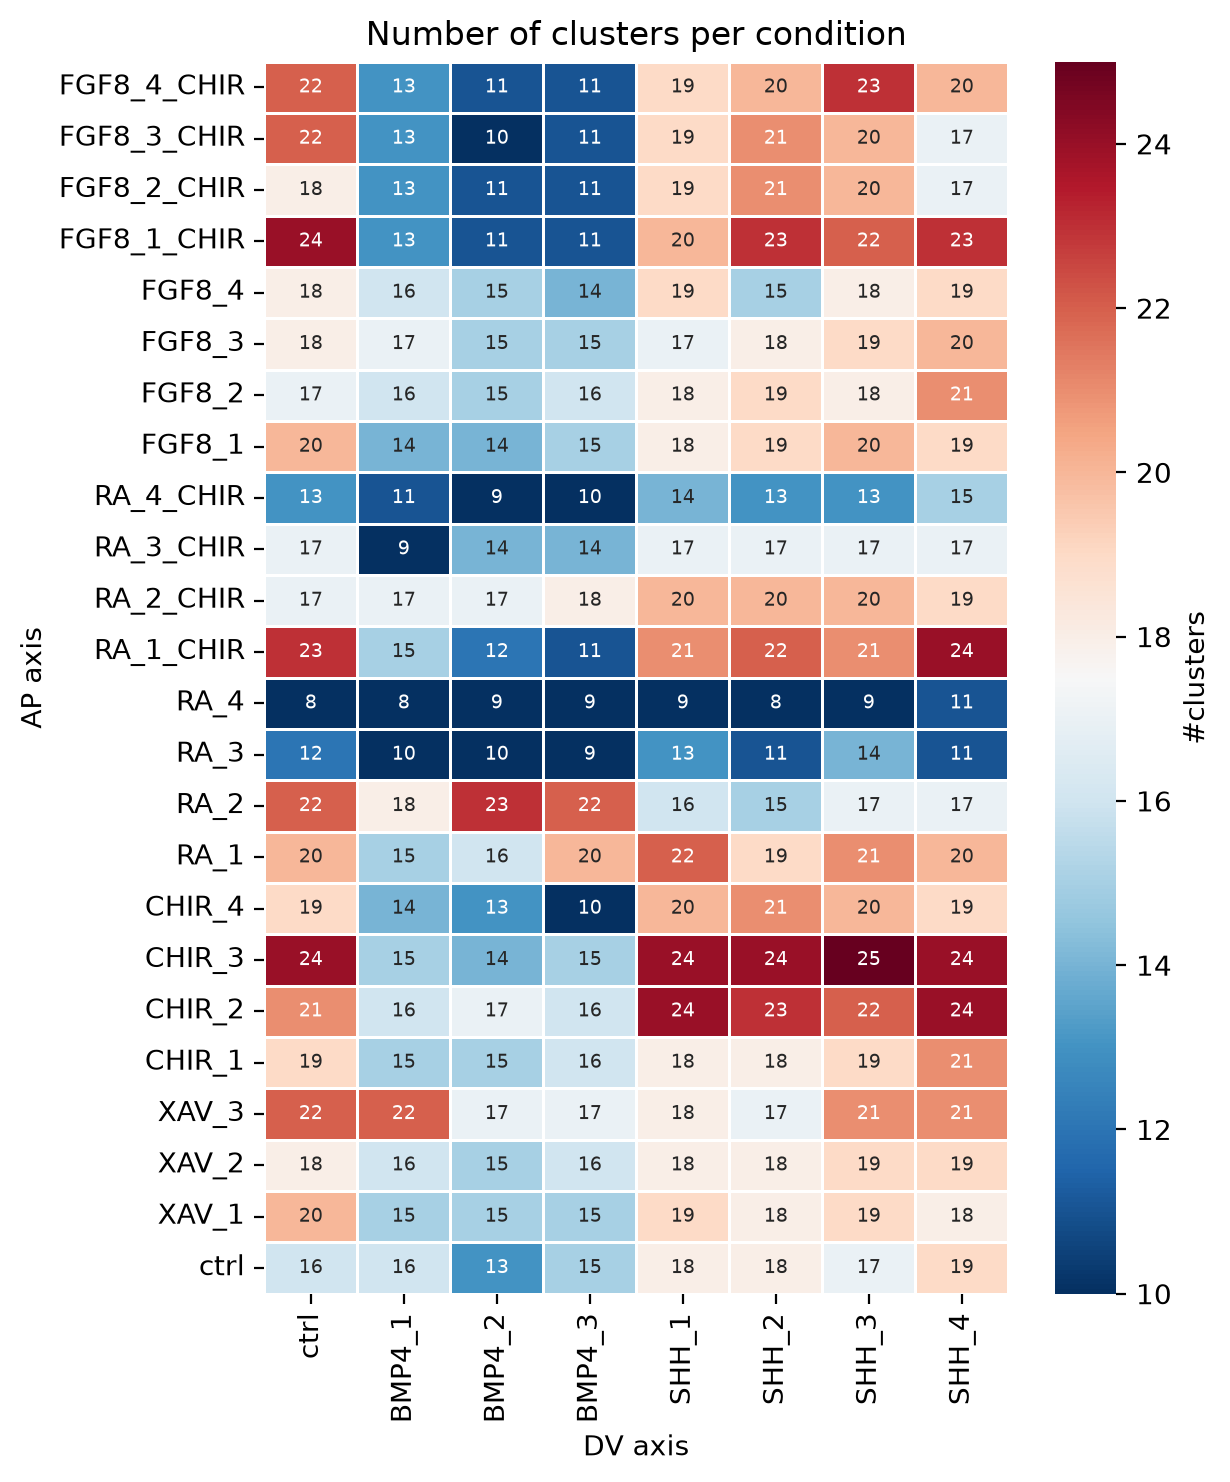

In [39]:
# number of clusters present (>0.5% of the sample) in each condition
PRES = 0.005
ncl = ((obs.groupby(["AP_axis", "DV_axis"], observed=True)["cell_type"]
          .value_counts(normalize=True).unstack(fill_value=0)) > PRES).sum(axis=1)
C = ncl.unstack("DV_axis").reindex(index=AP_ORDER[::-1], columns=DV_ORDER)

# BASIC PLOT: a single seaborn.heatmap, with the numbers written in
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(C, cmap="RdBu_r", vmin=10, vmax=25, annot=True, fmt=".0f",
            annot_kws={"size": 7}, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "#clusters"}, ax=ax)
ax.set_xlabel("DV axis"); ax.set_ylabel("AP axis")
ax.set_title("Number of clusters per condition")
plt.show()